<a href="https://colab.research.google.com/github/Sanat1427/USL-LAB/blob/main/coin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coin 1 area: 17058.00 pixels
Coin 2 area: 34384.00 pixels
Coin 3 area: 34138.50 pixels
Coin 4 area: 17035.50 pixels
Coin 5 area: 10168.50 pixels
Coin 6 area: 10165.00 pixels
Coin 7 area: 44352.00 pixels
Coin 8 area: 10161.50 pixels
Coin 9 area: 11058.00 pixels
Coin 10 area: 10164.50 pixels
Coin 11 area: 10158.00 pixels
Coin 12 area: 10141.00 pixels
Coin 13 area: 10155.00 pixels
Coin 14 area: 10165.50 pixels
Coin 15 area: 12779.50 pixels
Coin 16 area: 13178.00 pixels
Coin 17 area: 13178.50 pixels
Coin 18 area: 13166.00 pixels
Coin 19 area: 13190.50 pixels
Coin 20 area: 10980.00 pixels
Coin 21 area: 11289.00 pixels
Coin 22 area: 11308.00 pixels
Coin 23 area: 11312.00 pixels
Coin 24 area: 11296.50 pixels
Coin 25 area: 11301.50 pixels
Coin 26 area: 11277.00 pixels
Coin 27 area: 11270.00 pixels
Coin 28 area: 11297.50 pixels
Coin 29 area: 11303.50 pixels
Total coins: 29


(np.float64(-0.5), np.float64(678.5), np.float64(954.5), np.float64(-0.5))

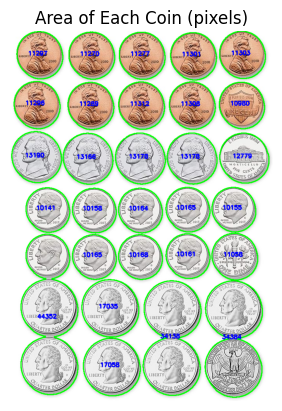

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read image
img = cv2.imread("coin.jpg")

# 2. Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Blur to remove noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 4. Binary conversion
_, binary = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# 5. Find contours
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 6. Calculate area of each coin
areas = []
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    areas.append(area)
    print(f"Coin {i+1} area: {area:.2f} pixels")

print("Total coins:", len(contours))

# 7. Draw contours and areas
output = img.copy()

for i, cnt in enumerate(contours):
    cv2.drawContours(output, [cnt], -1, (0, 255, 0), 2)

    # centroid
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.putText(
            output,
            f"{int(areas[i])}",
            (cx - 30, cy),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Area of Each Coin (pixels)")
plt.axis("off")

Number of coins: 33
Coin 1: Radius = 69 px | Area = 14957.12 pixels
Coin 2: Radius = 71 px | Area = 15836.77 pixels
Coin 3: Radius = 69 px | Area = 14957.12 pixels
Coin 4: Radius = 69 px | Area = 14957.12 pixels
Coin 5: Radius = 68 px | Area = 14526.72 pixels
Coin 6: Radius = 62 px | Area = 12076.28 pixels
Coin 7: Radius = 68 px | Area = 14526.72 pixels
Coin 8: Radius = 70 px | Area = 15393.80 pixels
Coin 9: Radius = 58 px | Area = 10568.32 pixels
Coin 10: Radius = 68 px | Area = 14526.72 pixels
Coin 11: Radius = 57 px | Area = 10207.03 pixels
Coin 12: Radius = 57 px | Area = 10207.03 pixels
Coin 13: Radius = 56 px | Area = 9852.03 pixels
Coin 14: Radius = 55 px | Area = 9503.32 pixels
Coin 15: Radius = 58 px | Area = 10568.32 pixels
Coin 16: Radius = 57 px | Area = 10207.03 pixels
Coin 17: Radius = 59 px | Area = 10935.88 pixels
Coin 18: Radius = 56 px | Area = 9852.03 pixels
Coin 19: Radius = 52 px | Area = 8494.87 pixels
Coin 20: Radius = 56 px | Area = 9852.03 pixels
Coin 21: Radiu

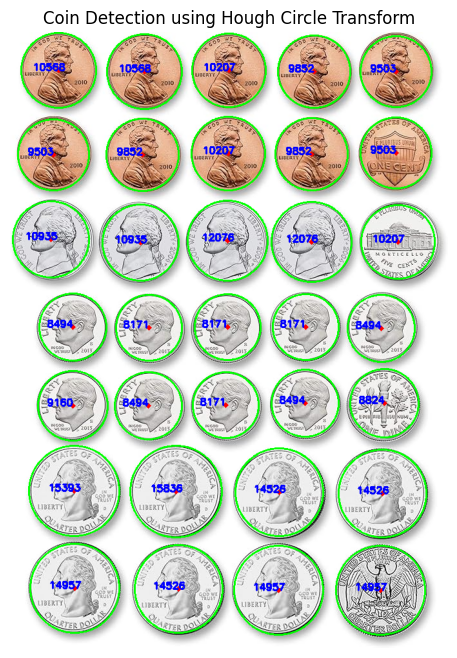

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image_path = "coin.jpg"
img = cv2.imread(image_path)




gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


gray = cv2.medianBlur(gray, 5)


circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=100,
    param2=70,
    minRadius=20,
    maxRadius=100
)


output = img.copy()
coin_areas = []

if circles is not None:
    circles = np.uint16(np.around(circles))
    total_coins = circles.shape[1]

    print("Number of coins:", total_coins)

    for i, (x, y, r) in enumerate(circles[0]):
        # Draw circle boundary
        cv2.circle(output, (x, y), r, (0, 255, 0), 2)
        # Draw center
        cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

        # Area in pixels
        area = np.pi * (r ** 2)
        coin_areas.append(area)

        print(f"Coin {i+1}: Radius = {r} px | Area = {area:.2f} pixels")

        # Label area on image
        cv2.putText(
            output,
            f"{int(area)}",
            (x - 40, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

else:
    print("No coins detected.")


plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Coin Detection using Hough Circle Transform")
plt.axis("off")
plt.show()